# 04 — Trust Classifier

**Goal:** predict the verified-purchase proxy from linguistic + behavioral signals (KNN, random forest) with stratified CV + grid search; evaluate via ROC & PR. `product_verified_ratio` is dropped as label leakage (`models.LEAKY_FOR_PROXY`).

> **Weak-proxy caveat.** Label = Amazon *Verified Purchase* (purchase verification, **not** ground-truth deception). Strengthened with behavioral signals; validated against real fake-review labels in notebook 07.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src import utils, viz
config = utils.load_config()
utils.set_seeds(config["project"]["random_seed"])
viz.set_house_style()
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

In [2]:
from src import fallback_loader as fl, clean
raw = ROOT / "data" / "raw"
cats = sorted({p.name[:-9] for p in raw.glob("*.jsonl.gz") if not p.name.startswith("meta_")})
assert cats, "No data in data/raw/. Download a category (see notebook 01 / README)."
print("categories present:", cats)
df = clean.clean_reviews(pd.concat(
    [pd.DataFrame(fl.load_category(config, c, raw_dir=str(raw))) for c in cats], ignore_index=True))
print("reviews:", len(df), "| verified rate:", round((df["verified_purchase"] == True).mean(), 3))

categories present: ['Subscription_Boxes']
2026-06-09 02:57:14,961 | review_deception.fallback | INFO | Loaded 16216 reviews for category 'Subscription_Boxes' from Subscription_Boxes.jsonl.gz


2026-06-09 02:57:15,105 | review_deception.clean | INFO | Cleaned 16216 reviews (447 flagged exact-duplicate).


reviews: 16216 | verified rate: 0.88


### Train + evaluate (positive class = *unverified*, the reviews we want to flag)

In [3]:
from src import models
cfg = utils.deep_merge(config, {"modeling": {"cv_folds": 5, "knn": {"n_neighbors_grid": [11, 21]},
        "random_forest": {"n_estimators_grid": [300], "max_depth_grid": [None, 20]}}})
res = models.run_classification(df, cfg)
for n, ev in res["results"].items():
    print(n, "ROC-AUC", round(ev["roc_auc"], 3), "AP", round(ev["average_precision"], 3), ev["best_params"])

2026-06-09 02:57:19,158 | review_deception.features | INFO | Built feature table: 16216 rows × 44 columns.


2026-06-09 02:57:21,609 | review_deception.models | INFO | knn: CV roc_auc=0.729, test ROC-AUC=0.731


2026-06-09 02:57:30,626 | review_deception.models | INFO | random_forest: CV roc_auc=0.792, test ROC-AUC=0.800


knn ROC-AUC 0.731 AP 0.283 {'knn__n_neighbors': 21}
random_forest ROC-AUC 0.8 AP 0.383 {'max_depth': 20, 'n_estimators': 300}


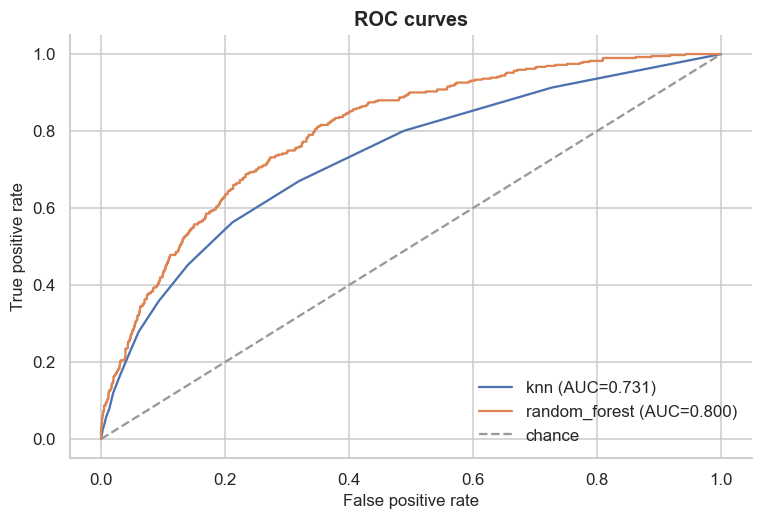

In [4]:
ax = viz.plot_roc_curves(res["results"]); viz.savefig(ax, str(FIG/"04_roc.png")); plt.show()

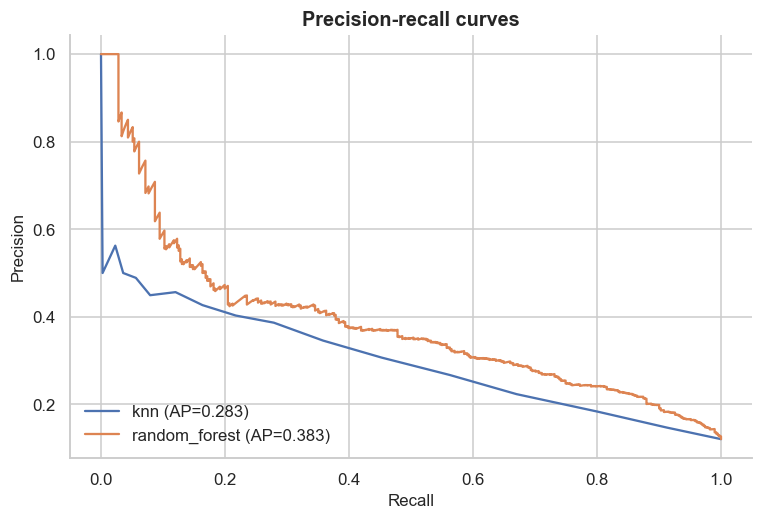

In [5]:
ax = viz.plot_pr_curves(res["results"]); viz.savefig(ax, str(FIG/"04_pr.png")); plt.show()

### What drives the prediction?

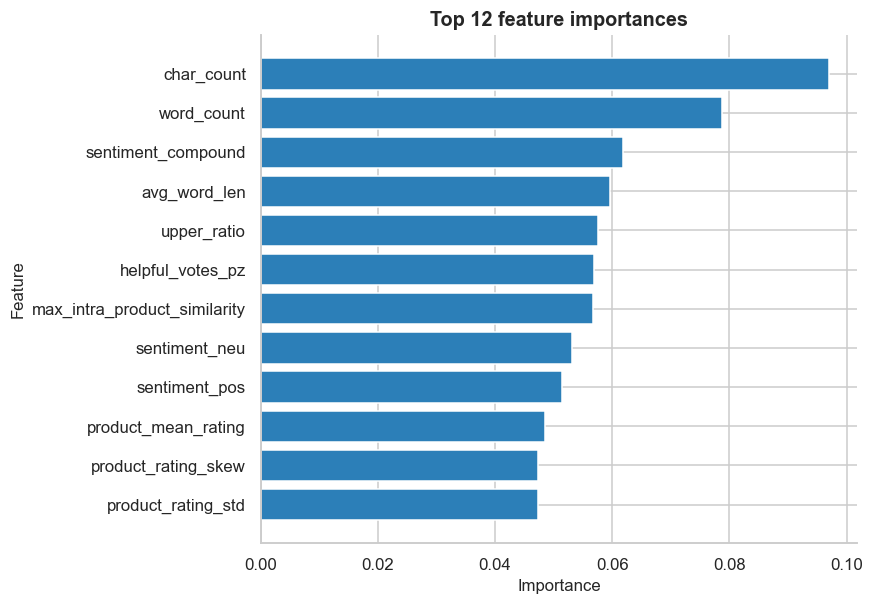

char_count                      0.0970
word_count                      0.0787
sentiment_compound              0.0618
avg_word_len                    0.0597
upper_ratio                     0.0575
helpful_votes_pz                0.0569
max_intra_product_similarity    0.0567
sentiment_neu                   0.0532


In [6]:
imp = res["results"]["random_forest"]["importances"]
ax = viz.plot_feature_importances(imp, top=12); viz.savefig(ax, str(FIG/"04_importances.png")); plt.show()
print(imp.head(8).round(4).to_string())

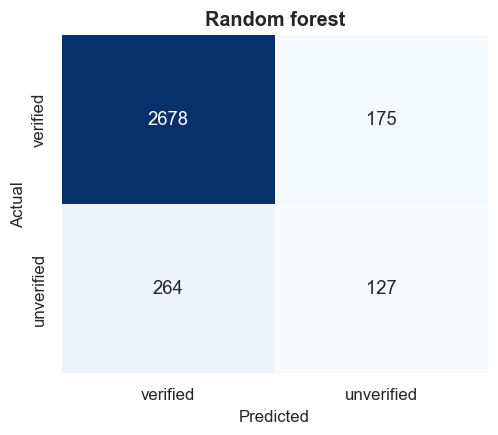

In [7]:
ev = res["results"]["random_forest"]
ax = viz.plot_confusion(ev["confusion_matrix"], ["verified","unverified"], title="Random forest")
viz.savefig(ax, str(FIG/"04_confusion.png")); plt.show()

**Findings.** Read the ROC-AUC and the top features above. Typically review **length/style** signals dominate; carry the strongest signals into notebook 07 to see which survive the real label.